<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_9/enc_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontro 9: Distribuições de probabilidade - a distribuição normal

**Instrutor**: Jhonatan Lopes

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

## A distribuição normal como objeto teórico

Uma distribuição de probabilidade é um **modelo matemático** que descreve os
valores possíveis de uma variável aleatória e como a probabilidade se distribui
entre esses valores.

Quando examinamos um histograma, uma ECDF ou um conjunto de números em um
DataFrame, estamos observando uma **amostra finita**. Uma distribuição de
probabilidade é um objeto teórico que pode ser usado para modelar o processo
gerador dessas observações.

Nesse contexto, **normal** possui um significado estatístico específico. O termo
não significa que os valores sejam comuns, corretos, esperados ou
estatisticamente “bons”: ele designa uma família particular de distribuições de
probabilidade.


### Distribuição normal padrão

Um membro especialmente importante dessa família possui:

$$
\mu = 0
$$

e

$$
\sigma = 1.
$$

Nesse caso:

$$
X \sim \mathcal{N}(0, 1).
$$


Ela é chamada **distribuição normal padrão**.

Como conhecemos os parâmetros dessa distribuição, podemos utilizá-la para
produzir amostras simuladas e observar como dados provenientes de uma
distribuição sabidamente normal se comportam.

In [2]:
rng = np.random.default_rng(
    seed=42
)

In [3]:
n_observacoes = 5_000

gaussian_values = rng.normal(
    loc=0,      # média
    scale=1,    # desvio-padrão
    size=n_observacoes,
)

gaussian_values[:10].round(3)

array([ 0.305, -1.04 ,  0.75 ,  0.941, -1.951, -1.302,  0.128, -0.316,
       -0.017, -0.853])

Os 5.000 números armazenados em `gaussian_values` constituem uma **amostra**.

A distribuição $\mathcal{N}(0,1)$ da qual eles foram gerados não contém apenas
esses 5.000 valores. Ela é uma distribuição contínua definida sobre toda a reta
real.

Valores muito distantes de zero continuam possíveis, embora se tornem
progressivamente menos prováveis à medida que nos afastamos do centro.

Uma nova amostra produzida pela mesma distribuição não conteria exatamente os
mesmos valores, mesmo que os parâmetros $\mu=0$ e $\sigma=1$ permanecessem
inalterados.

### Histograma da amostra simulada

O histograma resume os 5.000 valores observados agrupando-os em intervalos e
mostrando quantas observações aparecem em cada região da escala.

Como a amostra foi gerada de uma distribuição $\mathcal{N}(0,1)$, esperamos
maior concentração de valores próximos de zero e frequências progressivamente
menores à medida que nos afastamos do centro.

O histograma representa, porém, a **amostra simulada**. Ele não é a distribuição
teórica $\mathcal{N}(0,1)$.


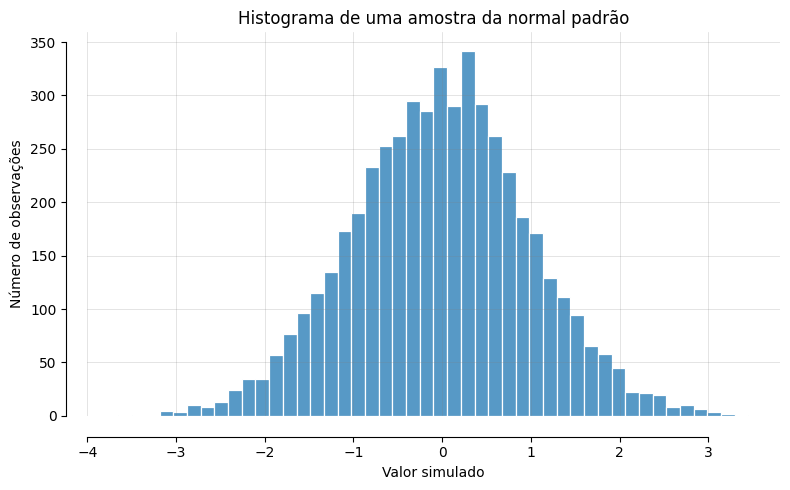

In [4]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

sns.histplot(
    x=gaussian_values,
    bins="fd",  # regra de Freedman–Diaconis
    stat="count",
    edgecolor="white",
    ax=ax,
)

ax.set(
    title="Histograma de uma amostra da normal padrão",
    xlabel="Valor simulado",
    ylabel="Número de observações",
)

ax.grid(
    alpha=0.3, linewidth=0.5, color="grey",
)

sns.despine(
    ax=ax, offset=15, trim=True, top=True,
)

plt.tight_layout()
plt.show()

### A mesma amostra representada por uma ECDF

O histograma agrupa os valores em intervalos. A ECDF representa a mesma amostra
de outra forma: para cada valor de $x$, mostra a proporção de observações da
amostra que são menores ou iguais a $x$.

Como estamos utilizando exatamente os mesmos 5.000 valores, a distribuição dos
dados não mudou. Mudou apenas a forma de representá-la.

Na região central, onde há maior concentração de observações, a ECDF cresce mais
rapidamente. Nas regiões extremas, onde as observações são menos frequentes, seu
crescimento é mais lento.


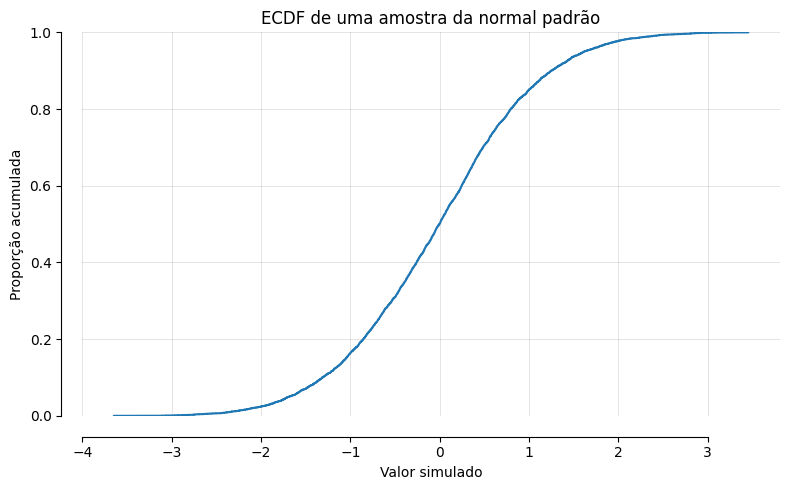

In [5]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

sns.ecdfplot(
    x=gaussian_values,
    stat="proportion",
    ax=ax,
)

ax.set(
    title="ECDF de uma amostra da normal padrão",
    xlabel="Valor simulado",
    ylabel="Proporção acumulada",
)

ax.grid(
    alpha=0.3, linewidth=0.5, color="grey",
)

sns.despine(
    ax=ax, offset=15, trim=True, top=True,
)

plt.tight_layout()
plt.show()

### Gráfico Q–Q: quantis observados e teóricos

O gráfico Q–Q compara os **quantis observados na amostra** com os quantis que
esperaríamos sob uma distribuição teórica de referência.

Neste caso, a referência é a distribuição normal. Se a estrutura dos quantis
observados for compatível com a estrutura dos quantis de uma distribuição
normal, os pontos tendem a se organizar aproximadamente ao longo de uma linha
reta.

Pequenos desvios são esperados mesmo quando a amostra foi realmente gerada de
uma distribuição normal, pois estamos observando uma realização aleatória e
finita. O gráfico Q–Q deve, portanto, ser interpretado como uma ferramenta
diagnóstica, e não como um teste binário de “normal” ou “não normal”.


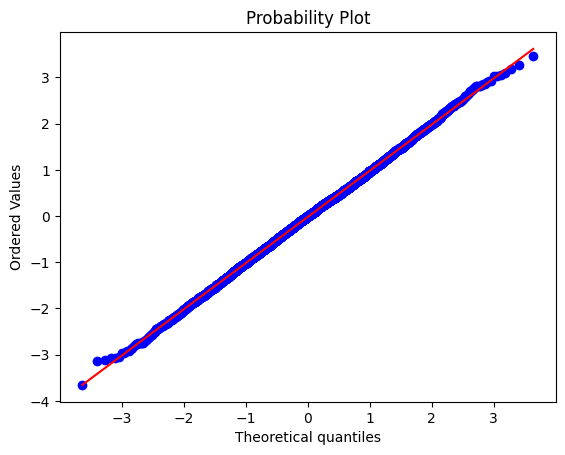

In [6]:
stats.probplot(
    x=gaussian_values,
    dist="norm",  # utiliza a distribuição gaussiana como referência teórica
    plot=plt,
)


plt.show()

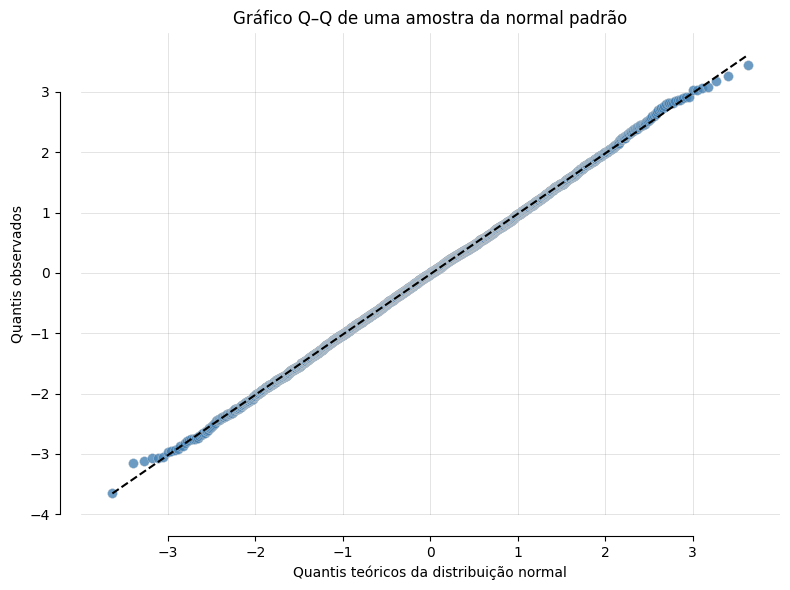

In [7]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

stats.probplot(
    x=gaussian_values,
    dist="norm",
    plot=ax,
)

points, reference_line = ax.lines

points.set(
    color="steelblue",
    markeredgecolor="lightgrey",
    markeredgewidth=0.3,
    markersize=7,
    alpha=0.8,
)

reference_line.set(
    color="black",
    linestyle="--",
    linewidth=1.5,
)

ax.set(
    title="Gráfico Q–Q de uma amostra da normal padrão",
    xlabel="Quantis teóricos da distribuição normal",
    ylabel="Quantis observados",
)

ax.grid(
    alpha=0.3, linewidth=0.5, color="grey",
    )

sns.despine(
    ax=ax, offset=15, trim=True, top=True,
)

plt.tight_layout()
plt.show()

## Parâmetros e estatísticas

Esses valores pertencem à **distribuição teórica** e são seus
**parâmetros**. Um parâmetro descreve uma característica do modelo
probabilístico.

A partir dos 5.000 valores observados, podemos calcular quantidades como a média
amostral e o desvio-padrão amostral:

$$
\bar{x}
\qquad\text{e}\qquad
s.
$$

Essas quantidades são **estatísticas**, pois são calculadas a partir da
amostra.

Como uma amostra é uma realização aleatória e finita, suas estatísticas não
precisam coincidir exatamente com os parâmetros da distribuição que a gerou.
Nesta simulação, como temos uma amostra relativamente grande, esperamos que
$\bar{x}$ esteja próximo de $\mu$ e que $s$ esteja próximo de $\sigma$.


In [8]:
sample_mean = gaussian_values.mean()

sample_std = gaussian_values.std(
    ddof=1
)

print(
    f"Média amostral: {sample_mean:.3f}"
)

print(
    f"Desvio-padrão amostral: {sample_std:.3f}"
)

Média amostral: -0.020
Desvio-padrão amostral: 0.999


No cálculo do desvio-padrão amostral, utilizamos `ddof=1`. Assim, a variância
associada ao cálculo utiliza `$n-1$` no denominador, em vez de `$n$`.

Essa é a forma usual de calcular a variância amostral quando a amostra é usada
para estimar a variabilidade de uma população ou distribuição.


## Os dois parâmetros da família normal

Uma distribuição normal é completamente determinada por dois parâmetros:

$$
X \sim \mathcal{N}(\mu,\sigma^2)
$$

Já vimos que $\mu$ descreve a posição da distribuição e $\sigma$ sua
dispersão. Podemos agora tornar esses efeitos visíveis por meio de simulações.

Começaremos alterando apenas um parâmetro de cada vez. Assim, podemos observar
o que acontece com as amostras quando a média muda enquanto o desvio-padrão
permanece constante e, depois, quando o desvio-padrão muda enquanto a média
permanece constante.

### O efeito da média $\mu$

Começaremos mantendo o desvio-padrão fixo em $\sigma=1$ e comparando
distribuições com médias iguais a $-2$, $0$ e $2$.

Como apenas $\mu$ varia, esperamos uma mudança na **posição** das distribuições,
sem alteração sistemática de sua dispersão.


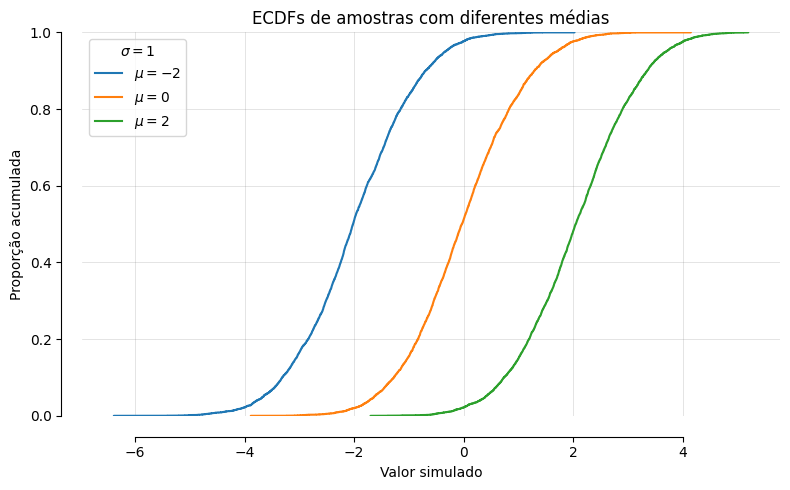

In [9]:
mu_values = [-2, 0, 2]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

for mu in mu_values:
    gaussian_sample = rng.normal(
        loc=mu,
        scale=1,
        size=n_observacoes,
    )

    sns.ecdfplot(
        x=gaussian_sample,
        stat="proportion",
        label=fr"$\mu={mu}$",
        ax=ax,
    )

ax.set(
    title="ECDFs de amostras com diferentes médias",
    xlabel="Valor simulado",
    ylabel="Proporção acumulada",
)

ax.legend(
    title=r"$\sigma=1$"
)

ax.grid(
    alpha=0.3, linewidth=0.5, color="grey",
    )

sns.despine(
    ax=ax, offset=15, trim=True, top=True,
)

plt.tight_layout()
plt.show()

As três ECDFs apresentam formas semelhantes, mas ocupam posições diferentes no
eixo horizontal. Quando $\mu$ aumenta, a distribuição se desloca para valores
maiores; quando $\mu$ diminui, desloca-se para valores menores.

Como $\sigma$ permanece fixo em $1$, a dispersão das três distribuições permanece
a mesma no modelo. As pequenas diferenças observadas entre as curvas decorrem da
variabilidade das amostras simuladas.


### O efeito do desvio-padrão $\sigma$

Examinaremos agora o segundo parâmetro da família gaussiana. Manteremos a média
fixa em $\mu=0$ e compararemos distribuições com desvios-padrão iguais a
$0{,}5$, $1$ e $2$.

Esses valores representam, respectivamente, metade, o mesmo valor e o dobro do
desvio-padrão da **normal padrão**.


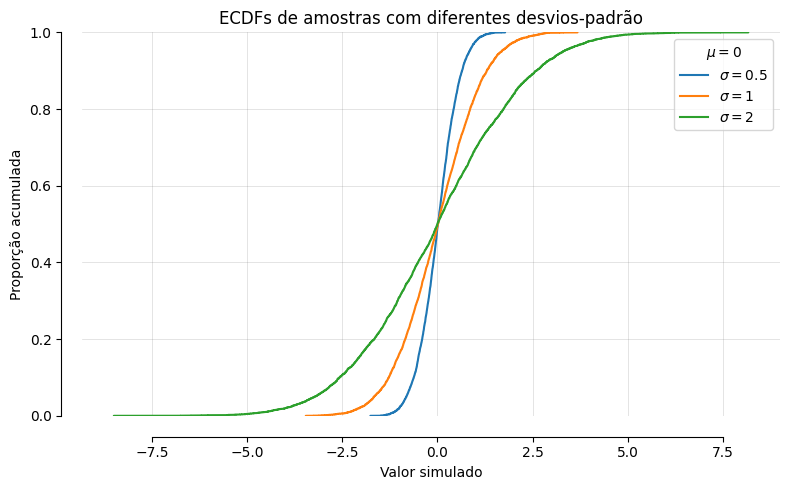

In [10]:
sigma_values = [0.5, 1, 2]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

for sigma in sigma_values:
    gaussian_sample = rng.normal(
        loc=0,
        scale=sigma,
        size=n_observacoes,
    )

    sns.ecdfplot(
        x=gaussian_sample,
        stat="proportion",
        label=fr"$\sigma={sigma}$",
        ax=ax,
    )

ax.set(
    title="ECDFs de amostras com diferentes desvios-padrão",
    xlabel="Valor simulado",
    ylabel="Proporção acumulada",
)

ax.legend(
    title=r"$\mu=0$"
)

ax.grid(
    alpha=0.3, linewidth=0.5, color="grey",
    )

sns.despine(
    ax=ax, offset=15, trim=True, top=True,
)

plt.tight_layout()
plt.show()

As três distribuições permanecem centradas em $\mu=0$, mas diferem em
dispersão.

Quando $\sigma$ é menor, os valores ficam mais concentrados ao redor da média e
a ECDF sobe mais rapidamente na região central. Quando $\sigma$ é maior, os
valores ocupam uma faixa mais ampla e a ECDF cresce mais gradualmente.

Como a média é a mesma nas três distribuições, suas ECDFs passam aproximadamente
pelo mesmo ponto central:

$$
F(0) \approx 0{,}5.
$$

### As mesmas amostras vistas lado a lado

Para encerrar, compararemos as duas famílias de amostras em três
representações lado a lado: histograma, ECDF e densidade estimada.

Até aqui, cada gráfico simulou sua própria amostra dentro do código. Para
examinar as mesmas amostras em mais de uma representação, vamos primeiro
organizá-las em duas tabelas: uma com médias diferentes e desvio-padrão fixo,
outra com desvios-padrão diferentes e média fixa.

Cada coluna recebe como nome o parâmetro que a gerou. O seaborn utiliza os
nomes das colunas como rótulos da legenda, de modo que as curvas ficam
identificadas automaticamente.

In [11]:
# Uma coluna por média: colunas nomeadas pelo parâmetro que as gerou.
gaussian_means = pd.DataFrame()

for mu in mu_values:
    gaussian_means[fr"$\mu={mu}$"] = rng.normal(
        loc=mu,
        scale=1,
        size=n_observacoes,
    )

# Uma coluna por desvio-padrão, com a média fixa em zero.
gaussian_stds = pd.DataFrame()

for sigma in sigma_values:
    gaussian_stds[fr"$\sigma={sigma}$"] = rng.normal(
        loc=0,
        scale=sigma,
        size=n_observacoes,
    )

gaussian_means.sample(n=5, random_state=42)

,$\mu=-2$,$\mu=0$,$\mu=2$
1501,-1.187627,-1.648817,3.895412
2586,-0.930917,-1.441461,0.948783
2653,-1.324652,-0.034019,3.429375
1055,-2.028387,-1.290734,1.916755
705,-2.788302,-0.737007,2.908925


### Comparação das mesmas amostras em três representações

Compararemos agora as duas famílias de amostras utilizando três representações:
histograma, ECDF e densidade estimada por KDE.

Nos gráficos anteriores, cada trecho de código gerou uma nova amostra. Para que
a comparação entre representações seja direta, utilizaremos agora exatamente os
**mesmos valores simulados** em cada uma delas.

Organizaremos essas amostras em duas tabelas: uma com médias diferentes e
desvio-padrão fixo e outra com desvios-padrão diferentes e média fixa. Cada
coluna corresponde a uma amostra gerada por uma combinação específica de
parâmetros.


## Escalas dos gráficos
O histograma será representado em **escala de densidade**, de modo que sua área
total seja igual a 1. Isso permite compará-lo diretamente com a KDE, cuja
escala vertical também representa densidade.

A ECDF utiliza outra escala: seu eixo vertical representa a proporção acumulada
de observações e varia de 0 a 1.

Em todos os casos, cada amostra será escalada separadamente. Assim, diferenças
visuais entre as curvas refletem principalmente diferenças de posição e
dispersão, e não o número de observações em cada série.


In [12]:
def compare_gaussians(gaussian_data) -> None:

    fig, (ax_hist, ax_ecdf, ax_kde) = plt.subplots(
        ncols=3,
        figsize=(16, 4),
        sharex=True,
        constrained_layout=True,
    )

    sns.histplot(
        data=gaussian_data,
        bins="fd",
        stat="density",
        common_norm=False,
        element="step",
        fill=True,
        alpha=0.5,
        ax=ax_hist,
    )

    sns.ecdfplot(
        data=gaussian_data,
        stat="proportion",
        ax=ax_ecdf,
    )

    sns.kdeplot(
        data=gaussian_data,
        fill=True,
        alpha=0.5,
        ax=ax_kde,
    )

    ax_hist.set(
        title="Histogramas",
        xlabel="Valor simulado",
        ylabel="Densidade",
    )

    ax_ecdf.set(
        title="ECDFs",
        xlabel="Valor simulado",
        ylabel="Proporção acumulada",
    )

    ax_kde.set(
        title="KDEs",
        xlabel="Valor simulado",
        ylabel="Densidade estimada",
    )

    for ax in [ax_hist, ax_ecdf, ax_kde]:
        ax.grid(
            alpha=0.3, linewidth=0.5, color="grey",
            )

    sns.despine(
        fig=fig,
        trim=True,
        offset=15,
    )

    plt.show()

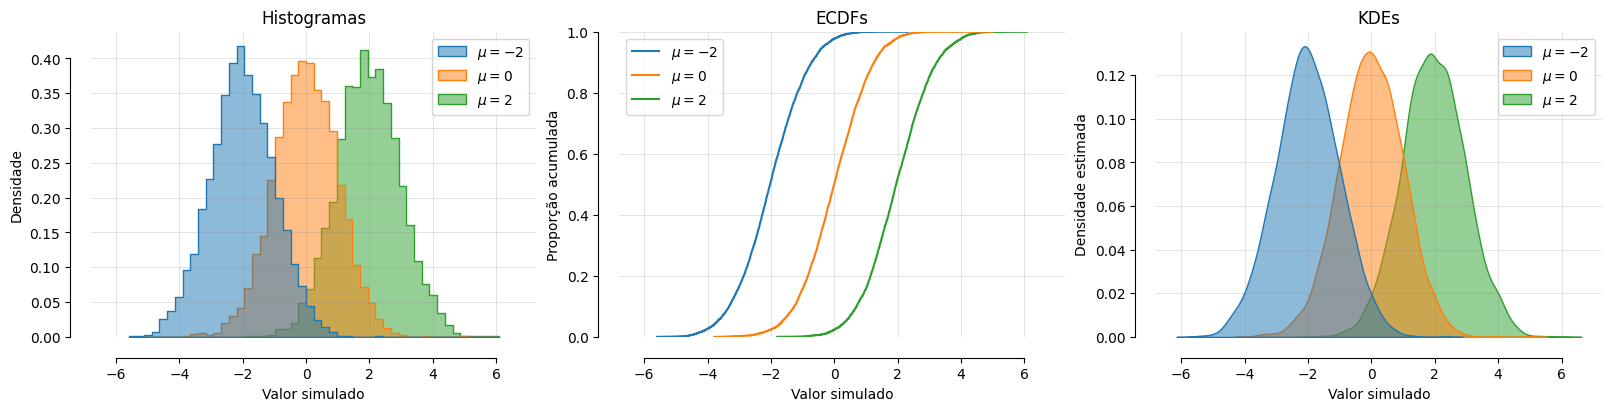

In [13]:
compare_gaussians(
    gaussian_data=gaussian_means
)

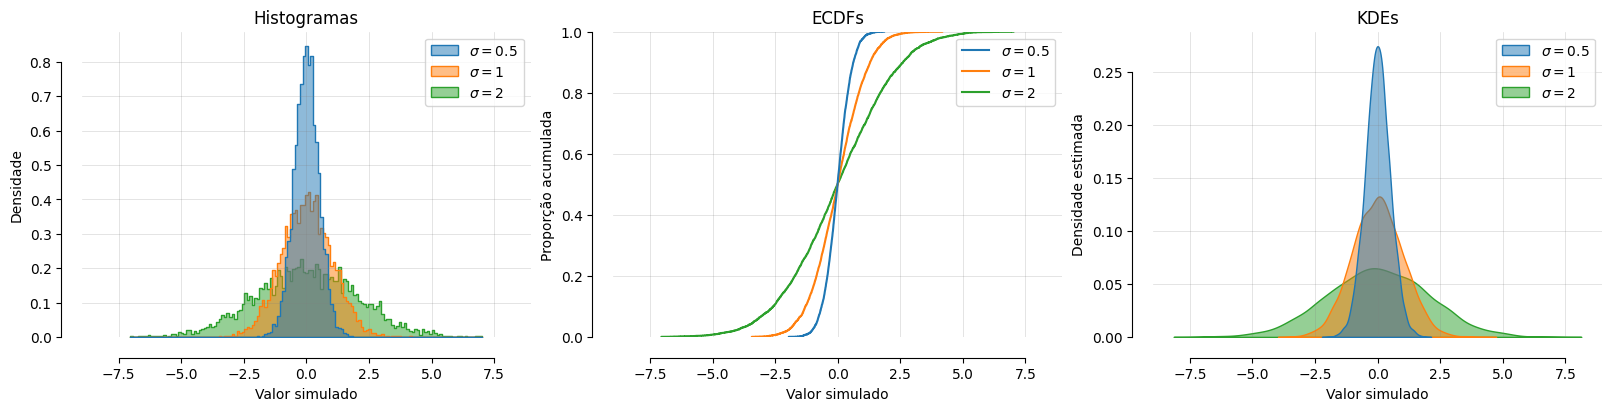

In [14]:
compare_gaussians(
    gaussian_data=gaussian_stds
)

Nas amostras com médias diferentes, as três representações mostram
essencialmente o mesmo deslocamento de posição. Os histogramas e as KDEs se
deslocam ao longo do eixo horizontal, enquanto as ECDFs mantêm formas
semelhantes em posições diferentes.

Quando alteramos o desvio-padrão, o centro permanece aproximadamente no mesmo
lugar e a dispersão muda. Os histogramas e as KDEs tornam-se mais largos à
medida que $\sigma$ aumenta, enquanto as ECDFs sobem mais gradualmente na região
central.

Nos histogramas em escala de densidade e nas KDEs, distribuições mais dispersas
também apresentam picos mais baixos. Para cada amostra, a área total da
densidade é igual a 1; quando a dispersão aumenta, essa área é distribuída por
uma faixa mais extensa de valores.

As KDEs mostradas aqui são **estimativas de densidade obtidas a partir das
amostras simuladas**. Elas não são a função densidade teórica da distribuição
normal que gerou os dados.
